In [10]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple


rho_w = 1025.0       # [kg/m^3] Density of seawater
g = 9.81             # [m/s^2] Gravitational acceleration
Hs = 0.7            # [m] Significant wave height (Hm0)
sop = 0.04            # [s] Peak wave period
tan_beta = 1.0 / 3.0 # [-] Slope of the revetment (tan(beta) = 1/3 for 1:3 slope)
Tp = math.sqrt((Hs * 2 * math.pi) / (g * sop))          # [s] Peak period of the wave (T_p)
# --- Filter and Soil Properties ---

D = 0.15             # [m] Thickness of the top (impervious) layer
b = 0.10             # [m] Thickness of the filter layer beneath --reset=0.13
k = 0.3             # [m/s] Permeability of the filter layer
k_prime = 0.01       # [m/s] Permeability of the base layer below the filter

# --- Derived Parameter ---

Lambda = np.sqrt(D * b * k / k_prime)  # [m] Leakage length (controls pressure dissipation)

#----------------------------------------------------------------------------------------------------------------------------

# Step 1: Estimate mean period
Tm_1_0 = Tp / 1.1

# Step 2: Calculate wavelength
L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)

# Step 3: Calculate Iribarren number
xi_m_1_0 = tan_beta / np.sqrt(Hs / L_m_1_0)
print(f"Iribarren number: {xi_m_1_0:.3f}")
print(Tp)


Iribarren number: 1.515
3.347915243953695


In [2]:
from docx import Document
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

# Load the document
doc = Document("data.docx")

# Get the first table
table = doc.tables[0]

# Extract the table into a list of lists
data = []
for row in table.rows:
    data.append([cell.text.strip() for cell in row.cells])

# Convert to DataFrame
df = pd.DataFrame(data[1:], columns=data[0])

# Clean up column names (strip spaces, replace weird characters)
df.columns = [col.strip().replace("", "Δ") for col in df.columns]

# Check exact column names
print("Columns:", df.columns.tolist())

# Filter rows where Type == "CB" and Toplayer == "Rectangular blocks"
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
]

# Convert relevant columns to numeric
df_cb_rect["Hs/ΔD"] = pd.to_numeric(df_cb_rect["Hs/ΔD"], errors="coerce")
df_cb_rect["N"] = pd.to_numeric(df_cb_rect["N"], errors="coerce")

# Drop rows with missing numeric data
df_cb_rect = df_cb_rect.dropna(subset=["Hs/ΔD", "N", "Updated damage"])

# Define color mapping
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# Split into circles and crosses
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Add your own data point ---
my_N = 1000
my_damage = "d"

# Define densities
rho_s = 2300     # block density (kg/m³)
rho_w = 1000     # water density (kg/m³)

# Calculate Δ
Delta = (rho_s - rho_w) / rho_w

# Calculate Hs/(Δ·D)
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles["N"],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses["N"],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Plot your own data point
ax.scatter(
    my_N,
    my_Hs_Delta_D,
    color=damage_colors[my_damage],
    edgecolor='black',
    s=80,
    marker='s',
    linewidth=1.5
)

# Labels and title
ax.set_xlim(0, 2000)
ax.set_xlabel("N", fontsize=14)
ax.set_ylabel("Hs/ΔD", fontsize=14)
ax.set_title("Hs/ΔD vs N for Type CB with Rectangular blocks", fontsize=16)

# Remove legend entirely (no ax.legend call)

# Ticks formatting
ax.tick_params(axis='x', labelrotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Optional: print filtered dataframe
print(df_cb_rect)


ModuleNotFoundError: No module named 'docx'

In [14]:
# -*- coding: utf-8 -*-
%pip install python-docx --quiet
from docx import Document
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
from matplotlib.lines import Line2D

# --------- Set STIX Font ---------
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"

# Load the document
doc = Document("workfolder/doc_tables/data.docx")

# Get the first table
table = doc.tables[0]

# Extract the table into a list of lists
data = []
for row in table.rows:
    data.append([cell.text.strip() for cell in row.cells])

# Convert to DataFrame
df = pd.DataFrame(data[1:], columns=data[0])

# Clean up column names (strip spaces, replace symbols)
df.columns = [
    col.strip()
        .replace("", "Δ")
        .replace("", "ξ")
    for col in df.columns
]

# Check exact column names
print("Columns:", df.columns.tolist())

# Convert relevant columns to numeric
df["Hs/ΔD"] = pd.to_numeric(df["Hs/ΔD"], errors="coerce")

# Check if ξ column exists
xi_col_candidates = [col for col in df.columns if "ξ" in col]
if not xi_col_candidates:
    raise ValueError("Could not find a ξ column in the table. Check your table header names!")
xi_col_name = xi_col_candidates[0]
print(f"Using column: {xi_col_name}")

df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# Filter rows where Type == "CB" and Toplayer == "Rectangular blocks"
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=["Hs/ΔD", xi_col_name, "Updated damage"])

# Define color mapping
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# Split into circles and crosses
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Add your own data point ---
my_xi = 1.515       # <<-- Replace with your own ξₘ-10 value
my_damage = "d"

# Define densities
rho_s = 2300     # block density (kg/m³)
rho_w = 1000     # water density (kg/m³)

# Calculate Δ
Delta = (rho_s - rho_w) / rho_w

# Calculate Hs/(Δ·D)
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles[xi_col_name],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses[xi_col_name],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Plot your own data point
ax.scatter(
    my_xi,
    my_Hs_Delta_D,
    color=damage_colors[my_damage],
    edgecolor='black',
    s=80,
    marker='s',
    linewidth=1.5
)

# Add label with arrow
ax.annotate(
    "Abaqus Simulation\nH07 C30/37",
    xy=(my_xi, my_Hs_Delta_D),
    xytext=(my_xi - 0.35, my_Hs_Delta_D + 1),
    ha='right',
    va='center',
    fontsize=14,        # increased from 12
    color='black',
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=1.5
    )
)

# Labels and title
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=16)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=16)
# ax.set_title(r"$H_s/\Delta D$ vs $\xi_{m-10}$ for Type CB with Rectangular blocks", fontsize=18)

# Grid and styling
grid_color = 'gray'
ax.grid(True, linestyle='-', alpha=0.5, color=grid_color)

for spine in ax.spines.values():
    spine.set_color(grid_color)

ax.tick_params(axis='both', color=grid_color)
ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelcolor='black', labelsize=14)

# Legend2
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
    Line2D([0], [0], color='red', marker='s', markersize=10,
           linestyle='None', markeredgecolor='black', label='Abaqus Simulation'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

plt.tight_layout()

output_dir = "workfolder/doc_tables"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular.png")

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight'
)

print("Plot saved to:", output_path)

# Show figure
plt.show()

# Optional: print filtered dataframe
print(df_cb_rect)



The following command must be run outside of the IPython shell:

    $ pip install python-docx --quiet

The Python package manager (pip) can only be used from outside of IPython.
Please reissue the `pip` command in a separate terminal or command prompt.

See the Python documentation for more information on how to install packages:

    https://docs.python.org/3/installing/


ModuleNotFoundError: No module named 'exceptions'

In [6]:
python3 -m pip install exceptions

SyntaxError: invalid syntax (<ipython-input-6-1f881257eddf>, line 1)

In [13]:
%pip install --upgrade python-docx


The following command must be run outside of the IPython shell:

    $ pip install --upgrade python-docx

The Python package manager (pip) can only be used from outside of IPython.
Please reissue the `pip` command in a separate terminal or command prompt.

See the Python documentation for more information on how to install packages:

    https://docs.python.org/3/installing/


In [9]:
# -*- coding: utf-8 -*-
from docx2python import docx2python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# --------- Set STIX Font ---------
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"

# --------- Load DOCX and extract table ---------
doc_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\data.docx"
doc_result = docx2python(doc_path)

# Extract first table in first section
# Remove empty rows and columns
table_data = [[cell.strip() for cell in row] for row in doc_result.body[0][0] if any(cell.strip() for cell in row)]

# Convert to DataFrame
df = pd.DataFrame(table_data[1:], columns=table_data[0])

# Clean up column names
df.columns = [
    col.strip()
       .replace("", "Δ")
       .replace("", "ξ")
    for col in df.columns
]

# Check if required column exists
if "Hs/ΔD" not in df.columns:
    raise KeyError(f"'Hs/ΔD' not found in columns: {df.columns.tolist()}")

# Convert numeric columns
df["Hs/ΔD"] = pd.to_numeric(df["Hs/ΔD"], errors="coerce")

# Find ξ column automatically
xi_col_candidates = [col for col in df.columns if "ξ" in col]
if not xi_col_candidates:
    raise ValueError("Could not find a ξ column in the table.")
xi_col_name = xi_col_candidates[0]
df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# Filter relevant rows
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=["Hs/ΔD", xi_col_name, "Updated damage"])

# Define damage color mapping
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# Separate marker types
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Your own data point ---
my_xi = 1.515
my_damage = "d"
rho_s = 2300
rho_w = 1000
Delta = (rho_s - rho_w) / rho_w
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# --------- Plot ---------
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles[xi_col_name],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses[xi_col_name],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Your point
ax.scatter(
    my_xi,
    my_Hs_Delta_D,
    color=damage_colors[my_damage],
    edgecolor='black',
    s=80,
    marker='s',
    linewidth=1.5
)

# Label with arrow
ax.annotate(
    "Abaqus Simulation\nH07 C30/37",
    xy=(my_xi, my_Hs_Delta_D),
    xytext=(my_xi - 0.35, my_Hs_Delta_D + 1),
    ha='right',
    va='center',
    fontsize=14,
    color='black',
    arrowprops=dict(arrowstyle='-', color='gray', lw=1.5)
)

# Labels & formatting
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=18)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=18)

grid_color = 'gray'
ax.grid(True, linestyle='-', alpha=0.5, color=grid_color)
for spine in ax.spines.values():
    spine.set_color(grid_color)
ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=16)
ax.tick_params(axis='y', labelcolor='black', labelsize=16)

# Legend
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
    Line2D([0], [0], color='red', marker='s', markersize=10,
           linestyle='None', markeredgecolor='black', label='Abaqus Simulation'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

plt.tight_layout()

# Save
output_dir = os.path.dirname(doc_path)
output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular.png")
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print("Plot saved to:", output_path)

plt.show()


IndexError: list index out of range

In [24]:
from docx2python import docx2python
import pandas as pd

# --- Path to your DOCX ---
doc_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\data.docx"

# --- Load DOCX ---
doc_result = docx2python(doc_path)

def flatten_cell(cell):
    """Flatten a docx2python cell to a single string."""
    if isinstance(cell, list):
        return " ".join(flatten_cell(sub) for sub in cell)
    return str(cell)

def find_data_table(body):
    """Recursively search for a table with >1 column and numeric-looking content."""
    for table in body:
        if isinstance(table, list):
            # If it's a table (list of rows)
            if all(isinstance(row, list) for row in table):
                flat_table = [[flatten_cell(cell).strip() for cell in row] for row in table]
                if len(flat_table) > 1 and len(flat_table[0]) > 1:
                    if any(any(char.isdigit() for char in cell) for row in flat_table for cell in row):
                        return flat_table
            # Search deeper
            found = find_data_table(table)
            if found:
                return found
    return None

# --- Find the data table ---
table_data = find_data_table(doc_result.body)
if not table_data:
    raise ValueError("No suitable data table found in .docx")

# --- Convert to DataFrame ---
df = pd.DataFrame(table_data[1:], columns=table_data[0])

# --- Clean column names ---
df.columns = [
    col.strip()
       .replace("\uf044", "Δ")  # Private-use Δ
       .replace("\uf078", "ξ")  # Private-use ξ
       .replace("\uf04c", "Λ")  # Private-use capital Lambda
       .replace("\uf061", "α")  # Private-use Greek alpha
       .replace("", "Δ")       # Symbol Δ from Word
       .replace("", "ξ")       # Symbol ξ from Word
       .replace("\xa0", " ")    # Non-breaking spaces
       .replace("  ", " ")      # Double spaces
    for col in df.columns
]

# --- Output for verification ---
print(df.head())
print(df.columns.tolist())


    ID Selection Type            Toplayer     Permeability remarks  \
0  122             CB  Armorflex elements  Geotextile under blocks   
1  124             CB  Armorflex elements  Geotextile under blocks   
2  123             CB  Armorflex elements  Geotextile under blocks   
3   49             CB    Haringman blocks            Wide y-joints   
4  115             CB    Haringman blocks                            

  Geometry remarks      D D/Bx  Λ/D cot α ξm-10   SWL z top    Hs Tm-10  \
0                   0.108  0.4  2.2     3  1.55     5  8.75  0.84   3.4   
1                   0.108  0.4  4.3     3  1.26     5  8.75  1.22   3.3   
2                   0.108  0.4  2.2     3  1.47     5  8.75  0.93   3.4   
3    On their side    0.2  2.0  2.5   3.5  1.65  4.98     5  1.56   5.8   
4                     0.2  0.4  3.0   3.5  1.24     5   8.5  1.33   4.0   

       N Hs/ΔD Damage Updated damage                  Reference  
0    552   5.5                     a      Lindenberg (1983), 4

In [23]:
from docx2python import docx2python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# --------- Set STIX Font ---------
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"

doc_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\data.docx"
doc_result = docx2python(doc_path)

def find_table_with_id(structure):
    """Find first table whose first header cell is 'ID'."""
    if isinstance(structure, list):
        # table candidate: list of rows (each row is list of cells)
        if structure and all(isinstance(r, list) for r in structure):
            first_row = [str(cell).strip() for cell in structure[0]]
            if first_row and first_row[0].lower() == "id" and len(first_row) > 5:
                return [[str(cell).strip() for cell in row] for row in structure]
        # search deeper
        for item in structure:
            result = find_table_with_id(item)
            if result:
                return result
    return None

table_data = find_table_with_id(doc_result.body)
if not table_data:
    raise ValueError("Could not find the CB data table with 'ID' header.")

# Convert to DataFrame
df = pd.DataFrame(table_data[1:], columns=table_data[0])

# Clean column names
df.columns = [
    col.strip()
       .replace("\uf044", "Δ")
       .replace("\uf078", "ξ")
       .replace("", "Δ")
       .replace("", "ξ")
       .replace("\xa0", "")
    for col in df.columns
]
print("Extracted columns:", df.columns.tolist())

# Identify columns
hs_col_candidates = [c for c in df.columns if "Hs" in c and "Δ" in c]
if not hs_col_candidates:
    raise ValueError("No Hs/ΔD column found.")
hs_col_name = hs_col_candidates[0]

xi_col_candidates = [c for c in df.columns if "ξ" in c]
if not xi_col_candidates:
    raise ValueError("No ξ column found.")
xi_col_name = xi_col_candidates[0]

# Convert numeric columns
df[hs_col_name] = pd.to_numeric(df[hs_col_name], errors="coerce")
df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# Filter for CB Rectangular blocks
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=[hs_col_name, xi_col_name, "Updated damage"])

# Damage colors
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# Separate points
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# Custom point
my_xi = 1.515
my_damage = "d"
rho_s = 2300
rho_w = 1000
Delta = (rho_s - rho_w) / rho_w
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df_circles[xi_col_name], df_circles[hs_col_name],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black', s=80, marker='o'
)
ax.scatter(
    df_crosses[xi_col_name], df_crosses[hs_col_name],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black', s=80, marker='+', linewidth=2
)
ax.scatter(
    my_xi, my_Hs_Delta_D,
    color=damage_colors[my_damage], edgecolor='black', s=80,
    marker='s', linewidth=1.5
)

# Label
ax.annotate(
    "Abaqus Simulation\nH07 C30/37",
    xy=(my_xi, my_Hs_Delta_D), xytext=(my_xi - 0.35, my_Hs_Delta_D + 1),
    ha='right', va='center', fontsize=14, color='black',
    arrowprops=dict(arrowstyle='-', color='gray', lw=1.5)
)

# Style
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=18)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=18)
ax.grid(True, linestyle='-', alpha=0.5, color='gray')
for spine in ax.spines.values():
    spine.set_color('gray')
ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=16)
ax.tick_params(axis='y', labelcolor='black', labelsize=16)

# Legend
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
    Line2D([0], [0], color='red', marker='s', markersize=10,
           linestyle='None', markeredgecolor='black', label='Abaqus Simulation'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

# Save
output_dir = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular.png")
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print("Plot saved to:", output_path)

plt.show()


ValueError: Could not find the CB data table with 'ID' header.

C:\Users\tpennock\AppData\Local\Temp\ipykernel_17716\3751342490.py:120: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family ['STIX Two Text'] not found. Falling back to DejaVu Sans.


Columns: ['ID', 'Selection', 'Type', 'Toplayer', 'Permeability remarks', 'Geometry remarks', 'D', 'D/Bx', 'Λ/D', 'cot α', 'ξm-10', 'SWL', 'z top', 'Hs', 'Tm-10', 'N', 'Hs/ΔD', 'Damage', 'Updated damage', 'Reference']
Using column: ξm-10


findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font famil

Plot saved to: D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\Hs_Delta_D_vs_xim10_CB_Rectangular.png


findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font family 'STIX Two Text' not found.
findfont: Font famil

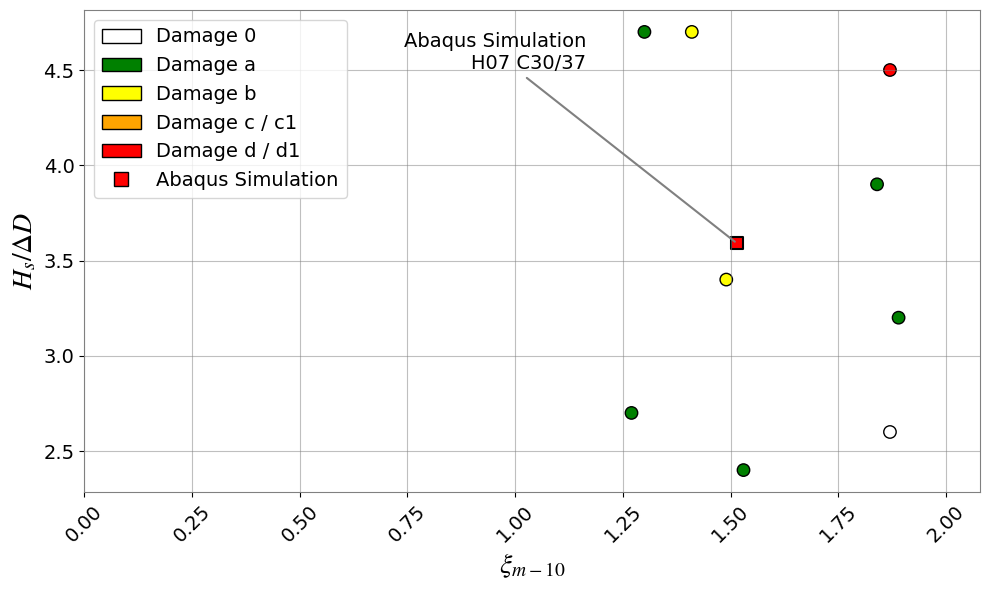

     ID Selection Type            Toplayer  Permeability remarks  \
10  190             CB  Rectangular blocks                         
11  191             CB  Rectangular blocks                         
12  192         *   CB  Rectangular blocks                         
13    7             CB  Rectangular blocks  Siltated, measured    
14    8             CB  Rectangular blocks  Siltated, measured    
15    9             CB  Rectangular blocks  Siltated, measured    
16   13             CB  Rectangular blocks            Mine stone   
17   13             CB  Rectangular blocks            Mine stone   
18   15             CB  Rectangular blocks                         

   Geometry remarks     D D/Bx  Λ/D cot α  ξm-10   SWL z top    Hs Tm-10  \
10                   0.18  0.6  0.6     3   1.53   4.5     7  0.58   2.8   
11                   0.18  0.6  0.6     3   1.49   4.5     7   0.8   3.2   
12                   0.18  0.6  0.6     3   1.87   4.5     7  1.08   4.7   
13             

In [1]:
# -*- coding: utf-8 -*-
from docx2python import docx2python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# --------- Set STIX Font ---------
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"

# --------- DOCX Reading with docx2python ---------
doc_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\data.docx"

def flatten_cell(cell):
    """Flatten a docx2python cell to a single string."""
    if isinstance(cell, list):
        return " ".join(flatten_cell(sub) for sub in cell)
    return str(cell)

def find_data_table(body):
    """Recursively search for a table with >1 column and numeric-looking content."""
    for table in body:
        if isinstance(table, list):
            if all(isinstance(row, list) for row in table):
                flat_table = [[flatten_cell(cell).strip() for cell in row] for row in table]
                if len(flat_table) > 1 and len(flat_table[0]) > 1:
                    if any(any(char.isdigit() for char in cell) for row in flat_table for cell in row):
                        return flat_table
            found = find_data_table(table)
            if found:
                return found
    return None

doc_result = docx2python(doc_path)
table_data = find_data_table(doc_result.body)
if not table_data:
    raise ValueError("No suitable data table found in .docx")

# Convert to DataFrame
df = pd.DataFrame(table_data[1:], columns=table_data[0])

# Clean up column names
df.columns = [
    col.strip()
        .replace("\uf04c", "Λ")   # private-use Λ
        .replace("\uf061", "α")   # private-use α
        .replace("\uf078", "ξ")   # private-use ξ
        .replace("\uf044", "Δ")   # private-use Δ
        .replace("", "Δ")        # possible alt Δ
        .replace("", "ξ")        # possible alt ξ
    for col in df.columns
]

print("Columns:", df.columns.tolist())

# --------- Convert Relevant Columns to Numeric ---------
df["Hs/ΔD"] = pd.to_numeric(df["Hs/ΔD"], errors="coerce")

xi_col_candidates = [col for col in df.columns if "ξ" in col]
if not xi_col_candidates:
    raise ValueError("Could not find a ξ column in the table. Check your table header names!")
xi_col_name = xi_col_candidates[0]
print(f"Using column: {xi_col_name}")
df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# --------- Filter Data ---------
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=["Hs/ΔD", xi_col_name, "Updated damage"])

# --------- Color Mapping ---------
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# --------- Split Markers ---------
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Add your own data point ---
my_xi = 1.515       # <<-- Replace with your own ξₘ-10 value
my_damage = "d"

# Densities
rho_s = 2300     # block density (kg/m³)
rho_w = 1000     # water density (kg/m³)

# Calculate Δ
Delta = (rho_s - rho_w) / rho_w

# Your case parameters
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# --------- Plot ---------
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles[xi_col_name],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses[xi_col_name],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Your point
ax.scatter(
    my_xi,
    my_Hs_Delta_D,
    color=damage_colors[my_damage],
    edgecolor='black',
    s=80,
    marker='s',
    linewidth=1.5
)

# Label with arrow
ax.annotate(
    "Abaqus Simulation\nH07 C30/37",
    xy=(my_xi, my_Hs_Delta_D),
    xytext=(my_xi - 0.35, my_Hs_Delta_D + 1),
    ha='right',
    va='center',
    fontsize=14,
    color='black',
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=1.5
    )
)

# Labels
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=20)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=20)

# Grid
grid_color = 'gray'
ax.grid(True, linestyle='-', alpha=0.5, color=grid_color)

for spine in ax.spines.values():
    spine.set_color(grid_color)

ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelcolor='black', labelsize=14)

# Legend
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
    Line2D([0], [0], color='red', marker='s', markersize=10,
           linestyle='None', markeredgecolor='black', label='Abaqus Simulation'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

plt.tight_layout()

# Save plot
output_dir = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular.png")
fig.savefig(output_path, dpi=300, bbox_inches='tight')

print("Plot saved to:", output_path)

# Show
plt.show()

# Optional: print filtered dataframe
print(df_cb_rect)


In [3]:
# -*- coding: utf-8 -*-
from docx2python import docx2python
import pandas as pd
import os

doc_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\data.docx"

def flatten_cell(cell):
    """Flatten a docx2python cell to a single string."""
    if isinstance(cell, list):
        return " ".join(flatten_cell(sub) for sub in cell)
    return str(cell)

def find_all_data_tables(body):
    """Recursively find ALL tables with >1 column and numeric-looking content."""
    tables_found = []
    for table in body:
        if isinstance(table, list):
            if all(isinstance(row, list) for row in table):
                flat_table = [[flatten_cell(cell).strip() for cell in row] for row in table]
                if len(flat_table) > 1 and len(flat_table[0]) > 1:
                    if any(any(char.isdigit() for char in cell) for row in flat_table for cell in row):
                        tables_found.append(flat_table)
            # Search deeper
            tables_found.extend(find_all_data_tables(table))
    return tables_found

# Read docx
doc_result = docx2python(doc_path)

# Get all tables
tables = find_all_data_tables(doc_result.body)
if not tables:
    raise ValueError("No suitable data tables found in .docx")

# Merge tables with same header
all_dfs = []
for t in tables:
    df_temp = pd.DataFrame(t[1:], columns=t[0])
    all_dfs.append(df_temp)

# Concatenate all into one DataFrame
df = pd.concat(all_dfs, ignore_index=True)

# Clean up column names
df.columns = [
    col.strip()
        .replace("\uf04c", "Λ")
        .replace("\uf061", "α")
        .replace("\uf078", "ξ")
        .replace("\uf044", "Δ")
        .replace("", "Δ")
        .replace("", "ξ")
    for col in df.columns
]

# Save CSV
output_dir = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "doc_table_extracted_all.csv")
df.to_csv(csv_path, index=False)

print("CSV saved to:", csv_path)
print("Rows extracted:", len(df))
print("Columns:", df.columns.tolist())


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import os

# --------- Set STIX Font (falls back if unavailable) ---------
try:
    plt.rcParams["font.family"] = "STIX Two Text"
    plt.rcParams["mathtext.fontset"] = "stix"
except Exception as e:
    print("Warning: Could not set STIX Two Text font, using default.", e)

# --------- Load CSV ---------
csv_path = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables\doc_table_extracted.csv"
df = pd.read_csv(csv_path)

# --------- Clean up column names ---------
df.columns = [col.strip() for col in df.columns]

# --------- Ensure numeric columns ---------
df["Hs/ΔD"] = pd.to_numeric(df["Hs/ΔD"], errors="coerce")

xi_col_candidates = [col for col in df.columns if "ξ" in col]
if not xi_col_candidates:
    raise ValueError("Could not find a ξ column in the CSV.")
xi_col_name = xi_col_candidates[0]
df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# --------- Filter Data ---------
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=["Hs/ΔD", xi_col_name, "Updated damage"])

# --------- Color Mapping ---------
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# --------- Split Markers ---------
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Add your own data point ---
my_xi = 1.515       # <<-- Replace with your own ξₘ-10 value
my_damage = "d"

# Densities
rho_s = 2300     # block density (kg/m³)
rho_w = 1000     # water density (kg/m³)

# Calculate Δ
Delta = (rho_s - rho_w) / rho_w

# Your case parameters
Hs = 0.7
D = 0.15
my_Hs_Delta_D = Hs / (Delta * D)

# --------- Plot ---------
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles[xi_col_name],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses[xi_col_name],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Your point
ax.scatter(
    my_xi,
    my_Hs_Delta_D,
    color=damage_colors[my_damage],
    edgecolor='black',
    s=80,
    marker='s',
    linewidth=1.5
)

# Label with arrow
ax.annotate(
    "Abaqus Simulation\nH07 C30/37",
    xy=(my_xi, my_Hs_Delta_D),
    xytext=(my_xi - 0.35, my_Hs_Delta_D + 1),
    ha='right',
    va='center',
    fontsize=14,
    color='black',
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=1.5
    )
)

# Labels
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=20)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=20)

# Grid
grid_color = 'gray'
ax.grid(True, linestyle='-', alpha=0.5, color=grid_color)

for spine in ax.spines.values():
    spine.set_color(grid_color)

ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelcolor='black', labelsize=14)

# Legend
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
    Line2D([0], [0], color='red', marker='s', markersize=10,
           linestyle='None', markeredgecolor='black', label='Abaqus Simulation'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

plt.tight_layout()

# Save plot
output_dir = r"D:\tpennock\GitHub\Thesis_Repository\workfolder\doc_tables"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular.png")
fig.savefig(output_path, dpi=300, bbox_inches='tight')

print("Plot saved to:", output_path)

plt.show()


Plot saved to: /Users/thomaspennock/Documents/TUDelft/Civiel2024-2025/ThesisPrep/Thesis_Repository-1/workfolder/doc_tables/Hs_Delta_D_vs_xim10_CB_Rectangular_annotated.pdf


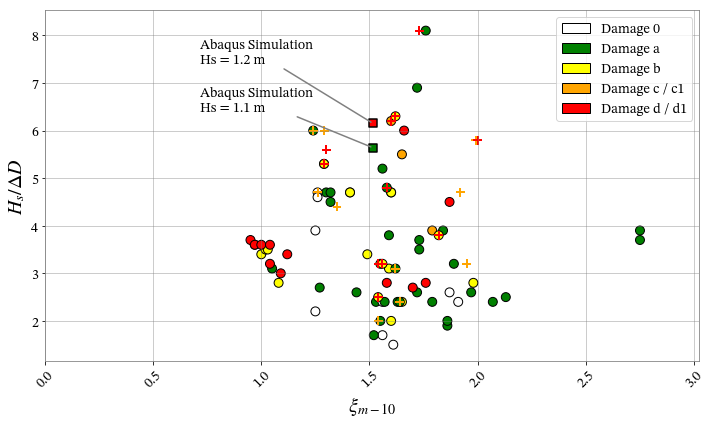

In [24]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import os

# --------- Load CSV ---------
csv_path = "/Users/thomaspennock/Documents/TUDelft/Civiel2024-2025/ThesisPrep/Thesis_Repository-1/workfolder/doc_tables/data_extracted.csv"
df = pd.read_csv(csv_path)

# --------- Clean column names ---------
df.columns = [
    col.strip()
        .replace("\uf04c", "Λ")
        .replace("\uf061", "α")
        .replace("\uf078", "ξ")
        .replace("\uf044", "Δ")
        .replace("", "Δ")
        .replace("", "ξ")
    for col in df.columns
]

# Convert to numeric where needed
df["Hs/ΔD"] = pd.to_numeric(df["Hs/ΔD"], errors="coerce")
xi_col_candidates = [col for col in df.columns if "ξ" in col]
if not xi_col_candidates:
    raise ValueError("Could not find a ξ column in the table!")
xi_col_name = xi_col_candidates[0]
df[xi_col_name] = pd.to_numeric(df[xi_col_name], errors="coerce")

# --------- Filter ---------
df_cb_rect = df[
    (df["Type"] == "CB") &
    (df["Toplayer"] == "Rectangular blocks")
].dropna(subset=["Hs/ΔD", xi_col_name, "Updated damage"])

# --------- Color Mapping ---------
damage_colors = {
    "0": "white",
    "a": "green",
    "b": "yellow",
    "c": "orange",
    "d": "red",
    "c1": "orange",
    "d1": "red",
}

# --------- Split Markers ---------
df_circles = df_cb_rect[~df_cb_rect["Updated damage"].isin(["c1", "d1"])]
df_crosses = df_cb_rect[df_cb_rect["Updated damage"].isin(["c1", "d1"])]

# --- Abaqus points ---
rho_s = 2300     # kg/m³
rho_w = 1000     # kg/m³
Delta = (rho_s - rho_w) / rho_w
D = 0.15
default_xi = 1.515


abaqus_points = [
    {"Hs": 1.1, "color": "green", "label": "Hs = 1.1 m",
     "offset": (-0.80, 1.00), "ha": "left", "va": "center"},
    {"Hs": 1.2, "color": "red",   "label": "Hs = 1.2 m",
     "offset": (-0.80, 1.50), "ha": "left", "va": "center"},

]

# --------- Plot ---------
fig, ax = plt.subplots(figsize=(10, 6))

# Circles
ax.scatter(
    df_circles[xi_col_name],
    df_circles["Hs/ΔD"],
    c=df_circles["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='o'
)

# Crosses
ax.scatter(
    df_crosses[xi_col_name],
    df_crosses["Hs/ΔD"],
    c=df_crosses["Updated damage"].map(damage_colors),
    edgecolor='black',
    s=80,
    marker='+',
    linewidth=2
)

# Abaqus points + individually placed annotations
for pt in abaqus_points:
    xi_val = pt.get("xi", default_xi)
    hs_delta_d = pt["Hs"] / (Delta * D)

    # Plot the square marker
    ax.scatter(
        xi_val,
        hs_delta_d,
        color=pt["color"],
        edgecolor='black',
        s=80,
        marker='s',
        linewidth=1.5,
        zorder=3
    )

    
    # Determine annotation text position
    if "xytext_abs" in pt:
        x_text, y_text = pt["xytext_abs"]
    else:
        dx, dy = pt.get("offset", (0.0, 0.0))
        x_text, y_text = xi_val + dx, hs_delta_d + dy

    ax.annotate(
        f"Abaqus Simulation\n{pt['label']}",
        xy=(xi_val, hs_delta_d),
        xytext=(x_text, y_text),
        ha=pt.get("ha", "left"),
        va=pt.get("va", "center"),
        fontsize=14,
        color='black',
        arrowprops=dict(arrowstyle='-', color='gray', lw=1.5)
    )

# Labels & grid
ax.set_xlim(0, df_cb_rect[xi_col_name].max() * 1.1)
ax.set_xlabel(r"$\xi_{m-10}$", fontsize=20)
ax.set_ylabel(r"$H_s/\Delta D$", fontsize=20)

grid_color = 'gray'
ax.grid(True, linestyle='-', alpha=0.5, color=grid_color)
for spine in ax.spines.values():
    spine.set_color(grid_color)
ax.tick_params(axis='x', labelcolor='black', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelcolor='black', labelsize=14)

# Legend (damage classes only; Abaqus is annotated)
legend_elements = [
    Patch(facecolor="white", edgecolor='black', label='Damage 0'),
    Patch(facecolor="green", edgecolor='black', label='Damage a'),
    Patch(facecolor="yellow", edgecolor='black', label='Damage b'),
    Patch(facecolor="orange", edgecolor='black', label='Damage c / c1'),
    Patch(facecolor="red", edgecolor='black', label='Damage d / d1'),
]
ax.legend(handles=legend_elements, fontsize=14, loc='best')

plt.tight_layout()

# Save as PDF instead of PNG
output_dir = os.path.dirname(csv_path)
output_path = os.path.join(output_dir, "Hs_Delta_D_vs_xim10_CB_Rectangular_annotated.pdf")
fig.savefig(output_path, dpi=300, bbox_inches='tight')

print("Plot saved to:", output_path)
plt.show()
